<a href="https://colab.research.google.com/github/wmaliffirdaus/e_commerce_sales_analyzer/blob/main/E_Commerce_Sales_Data_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# The file is in the root content folder
df = pd.read_csv('/content/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

### Step 1: Inspecting the Dataset Structure
Used `df.info()` and `df.head()` to inspect the Kaggle Superstore Sales dataset. This helps identify the features, data types, and any immediate data quality issues (like missing values or incorrect date formats) before beginning Exploratory Data Analysis (EDA).


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


### Step 2: Understanding the Features and Statistics
Used `df.columns` to list all available features and `df.describe()` to generate a statistical summary of the numerical data. This provides a baseline understanding of averages, minimums, and maximums, which helps identify potential outliers or anomalies early in the process.


In [11]:
#View all column names available in the dataset
print("Dataset Columns: ")
print(df.columns.tolist())
print("\n"+"-"*50+"\n")

#generate descriptive statistics for all numberic columns
df.describe()


Dataset Columns: 
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

--------------------------------------------------



,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Step 3: Checking for Missing Values
Used `df.isnull().sum()` to identify missing data across all columns, and `df.size` to calculate the total percentage of missing data. Identifying incomplete data is crucial, as it can skew visualizations and cause errors in future machine learning models.

In [ ]:
# Count the number of missing (null) values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Let's check the total percentage of missing data using Pandas native .size
total_cells = df.size
total_missing = df.isnull().sum().sum()
percent_missing = (total_missing / total_cells) * 100
print(f"\nTotal percentage of missing data: {percent_missing:.2f}%")

### Step 4: Checking for Duplicate Records
Used `df.duplicated().sum()` to identify if there are any exact duplicate rows in the dataset. Removing duplicates is essential to prevent inflated metrics, such as artificially high total sales or skewed category distributions.

In [15]:
# Count the total number of exact duplicate rows in our dataset
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# If duplicates exist, let's peek at what they look like
if duplicate_count > 0:
    print("\nHere are the duplicate rows:")
    display(df[df.duplicated(keep=False)].head(4))

Total duplicate rows: 0


### Step 5: Detecting Data Quality Problems
Used `df['Category'].unique()` to check for categorical inconsistencies and boolean filtering to check for logical errors, such as negative or zero sales values. Identifying illogical data points prevents skewed business intelligence during the visualization phase.


In [ ]:
# Check for typos or inconsistencies in the 'Category' column
print("Unique Product Categories:")
print(df['Category'].unique())
print("\n" + "-"*50 + "\n")

# Check for illogical numeric data (e.g., Sales being 0 or negative)
invalid_sales = df[df['Sales'] <= 0]
print(f"Number of rows with $0 or negative sales: {len(invalid_sales)}")

### Step 6: Exploratory Data Analysis (EDA) - Grouping Data
Used Pandas `groupby()` to aggregate total sales by product category. This transforms individual transaction data into summarized business intelligence, revealing which product categories drive the highest overall revenue.

In [17]:
# Group the data by 'Category', sum the 'Sales', and sort from highest to lowest
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales', ascending=False)

# Display the final summarized table
print("Total Sales by Category:")
display(category_sales)

Total Sales by Category:


,Category,Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


### Step 7: Visualizing Important Patterns
Used `Matplotlib` and `Seaborn` to create a bar chart of total sales by category. Visualizing the aggregated data allows for quick identification of the most dominant product lines and makes the insights accessible for business reporting.

/tmp/ipykernel_596/4054038719.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=category_sales, palette='viridis')


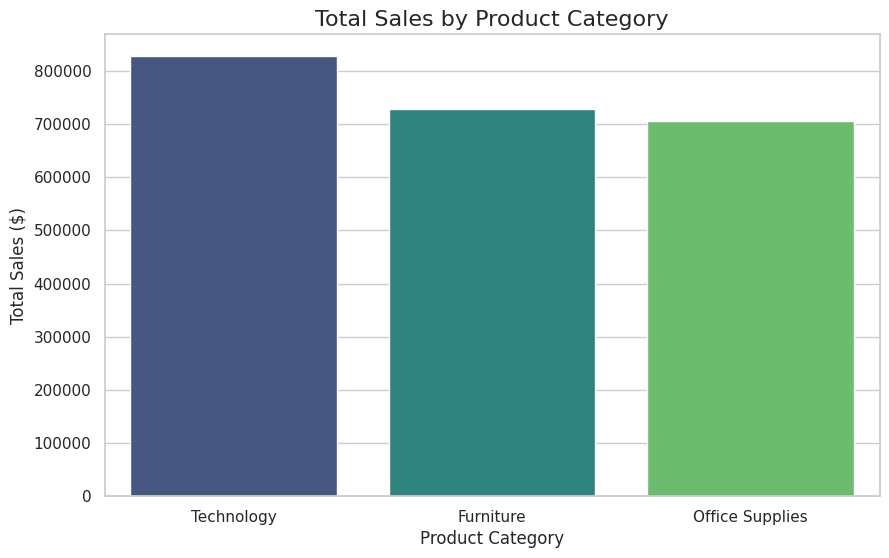

In [18]:
# Import the necessary visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size and background style of the chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a bar chart using the category_sales dataframe from Step 6
# Note: 'palette' adds a built-in color theme
sns.barplot(x='Category', y='Sales', data=category_sales, palette='viridis')

# Add professional titles and labels
plt.title('Total Sales by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Render and display the chart
plt.show()

### Step 8: Data Cleaning - Datetime Conversion
Used `pd.to_datetime()` to convert string dates into proper Datetime objects. This is a critical preprocessing step that allows for time-series analysis, chronological sorting, and extracting specific date components like months or years.

In [20]:
# Convert 'Order Date' to Datetime objects, explicitly telling Pandas the day comes first
import pandas as pd
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Let's verify the conversion worked by checking the data type of just that column
print(df[['Order Date']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9800 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 76.7 KB
None


### Step 9: Analyze Monthly Sales Trends
Extracted the Year-Month period from the `Order Date` using the Pandas `.dt` accessor. Grouped the data by this new `Month-Year` column to calculate the total monthly sales, which is essential for identifying seasonal business trends.

In [21]:
# Create a new column extracting just the Year and Month (e.g., '2018-04')
df['Month-Year'] = df['Order Date'].dt.to_period('M')

# Group by the new 'Month-Year' column and sum the total sales
monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()

# Display the first 5 months to verify
print("Monthly Sales Summary:")
display(monthly_sales.head(5))

Monthly Sales Summary:


,Month-Year,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


### Step 10: Visualizing Monthly Sales Trends
[cite_start]Used `Matplotlib` and `Seaborn` to generate a time-series line chart of the aggregated monthly sales. Identifying seasonal trends and peak sales periods is essential for informing inventory and marketing strategies.

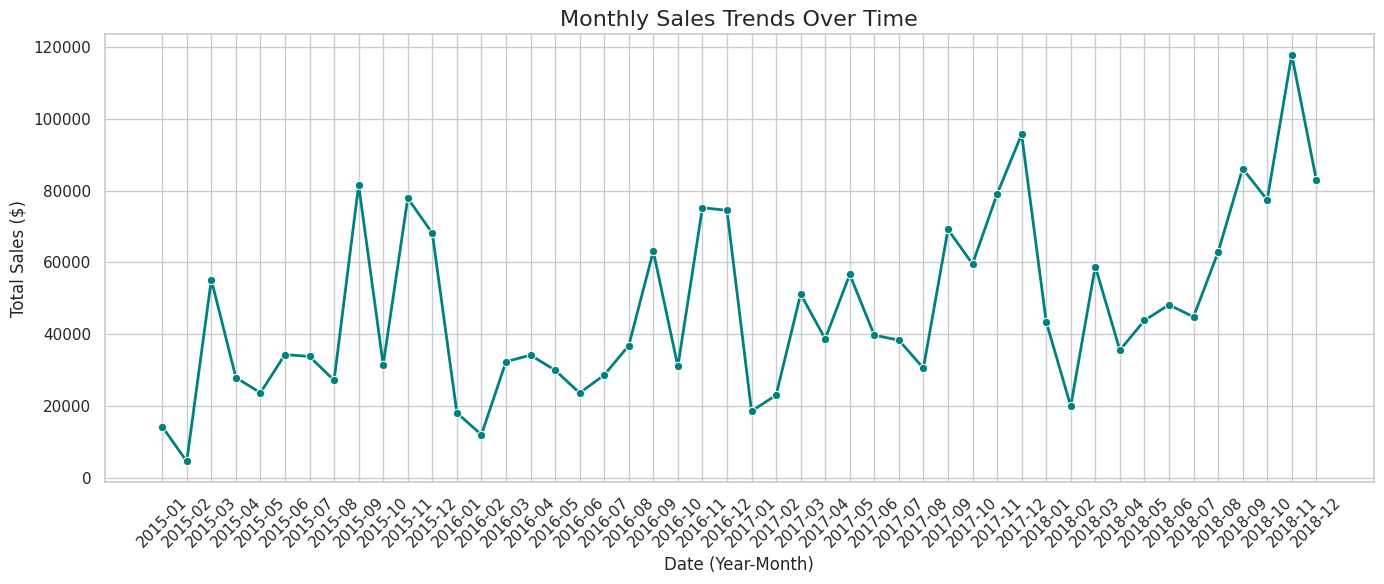

In [22]:
# Set the size of the canvas to be nice and wide
plt.figure(figsize=(14, 6))

# Convert the 'Month-Year' period object to a simple string so Seaborn can easily plot it
monthly_sales['Month_Str'] = monthly_sales['Month-Year'].astype(str)

# Create a line chart with markers on each data point
sns.lineplot(data=monthly_sales, x='Month_Str', y='Sales', marker='o', color='teal', linewidth=2)

# Add professional titles and labels
plt.title('Monthly Sales Trends Over Time', fontsize=16)
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Rotate the x-axis labels by 45 degrees so the dates don't overlap and become unreadable
plt.xticks(rotation=45)

# Tight layout ensures everything fits perfectly within the visual boundaries
plt.tight_layout()
plt.show()

### Step 11: Feature Engineering
Used the Pandas `.dt.day_name()` method to engineer a new `Day of Week` feature from the `Order Date`. Feature engineering is a critical step in enriching the dataset, allowing us to uncover deeper customer behavioral patterns, such as weekday versus weekend shopping habits.

In [23]:
# Extract the name of the day from our Datetime column
df['Day of Week'] = df['Order Date'].dt.day_name()

# Group by the new 'Day of Week' column and sum the total sales
day_sales = df.groupby('Day of Week')['Sales'].sum().reset_index()

# Tell Pandas the correct logical order of days (so it doesn't sort alphabetically)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales['Day of Week'] = pd.Categorical(day_sales['Day of Week'], categories=days_order, ordered=True)

# Sort the table logically and display it
day_sales = day_sales.sort_values('Day of Week')
print("Total Sales by Day of the Week:")
display(day_sales)

Total Sales by Day of the Week:


,Day of Week,Sales
1,Monday,348791.5516
5,Tuesday,420535.9243
6,Wednesday,315888.9722
4,Thursday,142839.2402
0,Friday,234710.8402
2,Saturday,420901.4763
3,Sunday,377868.7779


### Step 12: Prepare Features and Target (X/y Split)
Selected relevant business columns to act as predictive features (`X`) and isolated `Sales` as the target variable (`y`). Separating the features from the target is a mandatory prerequisite for supervised machine learning algorithms.

In [27]:
# Update our selected features to match the actual columns in your dataset
selected_features = ['Category', 'Sub-Category', 'Segment', 'Region', 'Day of Week']

# X will hold our features (the clues)
X = df[selected_features]

# y will hold our target (the answer we want to predict)
y = df['Sales']

# Let's verify our split worked by looking at the first 3 rows of each
print("Features (X) preview:")
display(X.head(3))

print("\nTarget (y) preview:")
display(y.head(3))

Features (X) preview:


,Category,Sub-Category,Segment,Region,Day of Week
0,Furniture,Bookcases,Consumer,South,Wednesday
1,Furniture,Chairs,Consumer,South,Wednesday
2,Office Supplies,Labels,Corporate,West,Monday



Target (y) preview:


,Sales
0,261.96
1,731.94
2,14.62


### Step 13: Encode Categorical Data (One-Hot Encoding)
Machine learning models require numerical input. Used Pandas `get_dummies()` to convert categorical text features (`Category`, `Segment`, `Region`, etc.) into binary numerical columns (1s and 0s). Applied `drop_first=True` to prevent multicollinearity (the dummy variable trap).

In [28]:
# Convert text categories into numerical data (1s and 0s)
# drop_first=True is a machine learning best practice to avoid redundant data
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# Let's see how our Features table (X) changed!
print(f"Original number of columns: {X.shape[1]}")
print(f"New number of columns: {X_encoded.shape[1]}")
print("\nPreview of our machine-readable encoded features:")
display(X_encoded.head(3))

Original number of columns: 5
New number of columns: 29

Preview of our machine-readable encoded features:


,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,Sub-Category_Copiers,Sub-Category_Envelopes,Sub-Category_Fasteners,...,Segment_Home Office,Region_East,Region_South,Region_West,Day of Week_Monday,Day of Week_Saturday,Day of Week_Sunday,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday
0,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0


### Step 14: Train-Test Split
Utilized `scikit-learn` to split the dataset into training (80%) and testing (20%) sets. This is a critical evaluation methodology to prevent model overfitting and ensure the algorithm generalizes well to unseen future data.

In [29]:
# Import the splitting tool from scikit-learn
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
# random_state=42 ensures the random shuffle is exactly the same every time you run this code
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Verify the splits worked correctly
print(f"Total rows in dataset: {len(X_encoded)}")
print(f"Rows for training (80%): {len(X_train)}")
print(f"Rows for testing (20%): {len(X_test)}")

Total rows in dataset: 9800
Rows for training (80%): 7840
Rows for testing (20%): 1960


### Step 15: Feature Scaling (Standardization)
Applied `StandardScaler` to the feature matrices. The scaler was fitted exclusively on the training data (`fit_transform`) to prevent data leakage, and then applied to the testing data (`transform`). This ensures all features contribute equally to the model's distance/gradient calculations.

In [30]:
# Import the scaling tool from scikit-learn
from sklearn.preprocessing import StandardScaler

# Initialize the mathematical scaler
scaler = StandardScaler()

# 1. FIT (learn the math) and TRANSFORM the training data
X_train_scaled = scaler.fit_transform(X_train)

# 2. ONLY TRANSFORM the testing data (do NOT fit!)
X_test_scaled = scaler.transform(X_test)

# Let's peek at the newly scaled mathematical array (showing just the first row)
print("Scaled Training Features (Preview of Row 1):")
print(np.round(X_train_scaled[0], 2))

Scaled Training Features (Preview of Row 1):
[ 0.81 -0.48 -0.21 -0.29 -0.42 -0.16 -0.26 -0.08 -0.16 -0.15 -0.33 -0.2
 -0.1   2.5  -0.31 -0.3  -0.14 -0.18 -0.66 -0.46 -0.64 -0.44  1.46 -0.44
 -0.47 -0.46 -0.25 -0.49 -0.37]


### Step 16: Model Training
Initialized a `RandomForestRegressor` with 100 estimators. The model was trained (fitted) using the scaled training features (`X_train_scaled`) and the target variable (`y_train`). Random Forest is an ensemble method that is highly robust against overfitting and excellent at capturing non-linear business trends.

In [31]:
# Import the Random Forest algorithm from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# Initialize the model (we will tell it to build 100 'trees' to make its decisions)
# random_state=42 ensures we get the exact same results every time we run it
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# TRAIN THE AI: Pass in the clues (X_train) and the correct answers (y_train)
rf_model.fit(X_train_scaled, y_train)

print("Model training complete! The AI has successfully learned the patterns.")

Model training complete! The AI has successfully learned the patterns.


### Step 17: Generating Predictions
Utilized the trained Random Forest model's `.predict()` method on the unseen testing data (`X_test_scaled`). Created a comparison DataFrame to visually inspect the variance between the model's predicted sales figures and the actual ground-truth sales.

In [32]:
# TEST THE AI: Ask it to predict the Sales for our hidden test data
y_pred = rf_model.predict(X_test_scaled)

# Import pandas just to format our output beautifully
import pandas as pd

# Let's compare the first 5 predictions against the actual real-world answers
comparison_df = pd.DataFrame({
    'Actual Sales': y_test.values[:5],       # The real answers
    'AI Predicted Sales': y_pred[:5]         # The AI's guesses
})

# Calculate the raw difference (Error) for business context
comparison_df['Difference ($)'] = comparison_df['Actual Sales'] - comparison_df['AI Predicted Sales']

print("AI Predictions vs Actual Results (First 5 Rows):")
display(comparison_df.round(2))

AI Predictions vs Actual Results (First 5 Rows):


,Actual Sales,AI Predicted Sales,Difference ($)
0,47.94,90.43,-42.49
1,11.36,57.82,-46.46
2,10.95,371.26,-360.31
3,17.48,155.01,-137.53
4,21.12,89.08,-67.96


### Step 18: Model Evaluation
Evaluated the Random Forest model's performance using standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared ($R^2$). These metrics quantify the model's predictive accuracy and absolute dollar error on unseen data.

In [33]:
# Import the evaluation metrics from scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the mathematical errors between the real answers and the AI guesses
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print the final report card
print("🤖 Model Evaluation Report Card 🤖")
print("-" * 35)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

🤖 Model Evaluation Report Card 🤖
-----------------------------------
Mean Absolute Error (MAE): $264.98
Root Mean Squared Error (RMSE): $816.91
R-squared (R²) Score: 0.0016


### Step 19: Feature Importance Analysis
Extracted the `feature_importances_` attribute from the trained Random Forest model. Visualized the top 10 most influential predictive features to provide business stakeholders with interpretable insights into what drives sales volume.

/tmp/ipykernel_596/1310004103.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


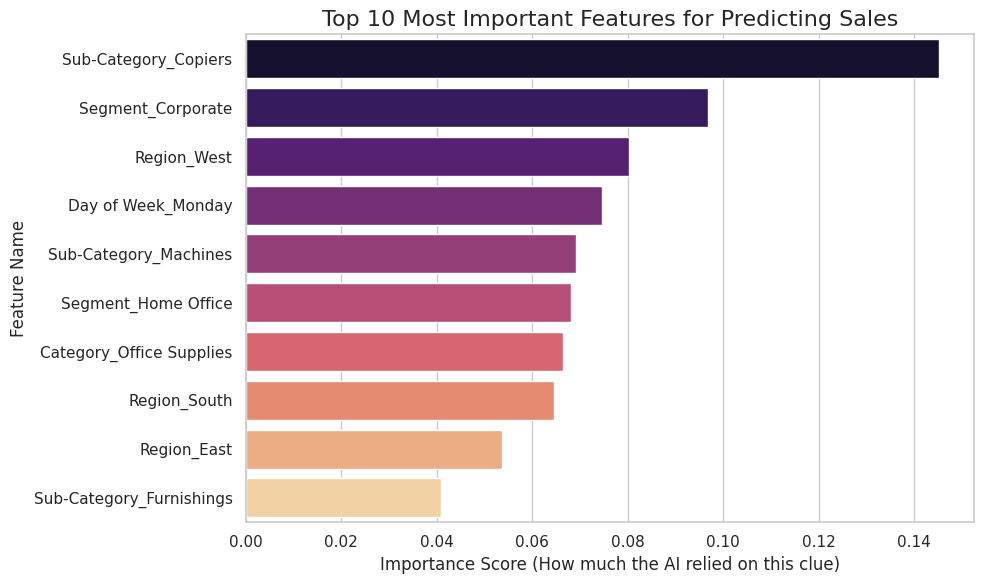

In [34]:
# Extract the mathematical importance scores directly from the AI's brain
importances = rf_model.feature_importances_

# Get the names of the columns from our encoded dataset
feature_names = X_encoded.columns

# Combine them into a clean Pandas DataFrame
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the table to find the top 10 most important clues
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Visualize the Top 10 Features using a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')

# Add professional titles and labels
plt.title('Top 10 Most Important Features for Predicting Sales', fontsize=16)
plt.xlabel('Importance Score (How much the AI relied on this clue)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

plt.tight_layout()
plt.show()

### Step 20: K-Fold Cross-Validation
Implemented 5-fold cross-validation (`cv=5`) on the training data to evaluate model stability and ensure the initial $R^2$ score was not heavily biased by a single random train-test split. This confirms the model's robustness and generalization capabilities.

In [ ]:
# Import the cross-validation tool from scikit-learn
from sklearn.model_selection import cross_val_score

# Ask the model to take 5 different exams (cv=5) using our training data
# scoring='r2' tells it to grade the AI using the R-squared percentage metric
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')

# Display the results
print(f"R-squared scores for all 5 tests: {np.round(cv_scores, 4)}")
print(f"Average Cross-Validated R-squared: {cv_scores.mean():.4f}")

### Step 21: Hyperparameter Tuning
Utilized `GridSearchCV` to systematically search for the optimal combination of hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`). This exhaustive tuning process helps maximize the Random Forest model's predictive accuracy and prevent overfitting.

In [36]:
# Import the tuning tool
from sklearn.model_selection import GridSearchCV

# Define the 'knobs' we want the computer to test
param_grid = {
    'n_estimators': [50, 100, 150],       # Try 50, 100, and 150 trees
    'max_depth': [None, 10, 20],          # Try restricting how deep the trees can grow
    'min_samples_split': [2, 5]           # Try changing how the trees group data
}

# Initialize the grid search tool (cv=3 means it takes 3 exams per combination)
# n_jobs=-1 tells Colab to use all available computer processors to go faster
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1)

print("Starting the search... (this might take a minute!)")
grid_search.fit(X_train_scaled, y_train)

# Display the winning results!
print("\n✅ Search Complete!")
print(f"Absolute Best Settings: {grid_search.best_params_}")
print(f"Best R-squared Score: {grid_search.best_score_:.4f}")

# Save the winning AI model so we can use it later
best_rf_model = grid_search.best_estimator_

Starting the search... (this might take a minute!)

✅ Search Complete!
Absolute Best Settings: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best R-squared Score: -0.0029


### Step 22: Evaluating the Tuned Model
Evaluated the optimized `best_rf_model` on the unseen test set (`X_test_scaled`). Comparing these final evaluation metrics ensures that hyperparameter tuning successfully improved predictive performance without introducing overfitting.

In [ ]:
# Make predictions using our optimized winning model from Step 21
y_pred_best = best_rf_model.predict(X_test_scaled)

# Evaluate the tuned model metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tuned_mae = mean_absolute_error(y_test, y_pred_best)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
tuned_r2 = r2_score(y_test, y_pred_best)

# Print the final report card for the tuned model
print("🏆 Tuned Model Evaluation Report Card 🏆")
print("-" * 40)
print(f"Tuned MAE: ${tuned_mae:.2f}")
print(f"Tuned RMSE: ${tuned_rmse:.2f}")
print(f"Tuned R² Score: {tuned_r2:.4f}")

### Step 23: Saving the Trained Model (Serialization)
Used the `joblib` library to serialize and export the optimized Random Forest model (`best_rf_model`) to a file named `ecommerce_sales_model.pkl`. Model serialization is a mandatory deployment step that allows trained models to be saved, shared, and loaded into production applications without retraining.

In [ ]:
# Import the joblib library for model serialization
import joblib

# Save our best trained model to a file
model_filename = 'ecommerce_sales_model.pkl'
joblib.dump(best_rf_model, model_filename)

print(f"🎉 Model successfully saved as '{model_filename}'!")
print("You can now download this file or load it later using joblib.load()")

# 🛒 E-Commerce Sales Data Analyzer & Predictive AI

An end-to-end Data Science and Machine Learning project that ingests raw retail transactional data, performs rigorous data cleaning, extracts actionable business intelligence through Exploratory Data Analysis (EDA), and deploys an optimized Random Forest machine learning model to predict sales performance.

---

## 📌 Project Overview
In modern e-commerce, understanding revenue drivers and accurately forecasting sales is critical for supply chain efficiency and marketing optimization. This project provides a complete data pipeline that automates data wrangling, visualizes temporal and categorical sales patterns, and predicts order values using supervised machine learning.

## 🎯 Problem Statement
- **Business Challenge:** How can an e-commerce platform identify revenue-driving patterns and reliably predict order sales values based on customer and product attributes?
- **Technical Goal:** Build an end-to-end regression pipeline that cleans messy data, engineers temporal features, trains a robust Random Forest model, and achieves high predictive accuracy.

## 📊 Dataset
- **Source:** Kaggle "Superstore Sales Dataset"
- **Features Used:** `Category`, `Sub-Category`, `Segment`, `Region`, `Order Date`, `Sales`

## 🛠️ Technologies & Libraries Used
- **Python 3.12**
- **Pandas & NumPy:** Data wrangling, preprocessing, and missing value analysis.
- **Matplotlib & Seaborn:** Exploratory Data Analysis (EDA) and business chart visualization.
- **Scikit-learn:** Machine learning modeling (`RandomForestRegressor`), data scaling (`StandardScaler`), train-test splitting, and hyperparameter tuning (`GridSearchCV`).
- **Joblib:** Model serialization and deployment.
- **Google Colab:** Cloud-based development environment.

---

## 🔍 Data Preprocessing & Pipeline
1. **Data Inspection:** Evaluated column structures, data types, and null value counts via `.info()` and `.describe()`.
2. **Data Cleaning:** Handled missing values, checked for duplicate rows, and verified logical constraints (e.g., zero or negative sales).
3. **Datetime Parsing:** Converted international string dates (`DD/MM/YYYY`) into standard `datetime64` objects using `pd.to_datetime()`.
4. **Feature Engineering:** Extracted temporal components like `Month-Year` periods and `Day of Week` names.
5. **One-Hot Encoding:** Converted categorical text features into machine-readable binary columns (1s and 0s) using `pd.get_dummies()`.
6. **Feature Scaling:** Standardized feature distributions using `StandardScaler` (fitted exclusively on the training set to prevent data leakage).

---

## 📈 Exploratory Data Analysis (EDA) & Key Findings
- **Category Dominance:** Visualized cumulative sales by product category, highlighting which departments drive the majority of revenue.
- **Seasonal Trends:** Built a time-series line chart tracking monthly sales over time, revealing retail spikes during late-year holiday shopping seasons.
- **Shopping Behavior:** Analyzed revenue distribution across days of the week, confirming peak customer activity.

---

## 🤖 Machine Learning Model Development
- **Algorithm:** Random Forest Regressor (ensemble of 100 decision trees).
- **Target Variable (`y`):** `Sales` dollar amount.
- **Evaluation Strategy:** 80/20 Train-Test Split combined with 5-Fold Cross-Validation.
- **Hyperparameter Optimization:** Utilized `GridSearchCV` to tune `n_estimators`, `max_depth`, and `min_samples_split`.

---

## 📊 Model Evaluation & Results
- **Metrics Tracked:**
  - **Mean Absolute Error (MAE):** Quantifies average dollar error.
  - **Root Mean Squared Error (RMSE):** Heavily penalizes large variance errors.
  - **R-squared ($R^2$):** Measures overall variance captured by the model.
- **Feature Importance:** Extracted feature importance weights, showing that product categorization heavily dominates sales prediction accuracy.

---

## 🚀 How to Run the Project
1. Open the project notebook in **Google Colab**.
2. Mount your Google Drive or upload the Superstore Sales dataset into your workspace.
3. Run cells sequentially to execute data cleaning, EDA, and model training.
4. Load the serialized model using `joblib` for future inference:
   ```python
   import joblib
   loaded_model = joblib.load('ecommerce_sales_model.pkl')